# Statistical Analysis - Air Quality Dataset

Basic statistical analysis and validation of the cleaned air quality data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Load Dataset

In [9]:
data = pd.read_csv('../Data/processed/clean_data.csv')
print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nFirst few rows:")
print(data.head())

Dataset shape: (425279, 13)

Columns: ['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'year', 'month', 'day', 'day_of_week', 'quality_level']

First few rows:
         date           state       area  number_of_monitoring_stations  \
0  2025-06-19   uttar pradesh       agra                            5.0   
1  2025-06-19       karnataka   bagalkot                            1.0   
2  2025-06-19     maharashtra      akola                            1.0   
3  2025-06-19       rajasthan      alwar                            1.0   
4  2025-06-19  andhra pradesh  amaravati                            1.0   

  prominent_pollutants  aqi_value air_quality_status  \
0        O3,PM2.5,PM10         49               Good   
1                 PM10         46               Good   
2                 PM10         26               Good   
3                   CO         76       Satisfactory   
4                 PM10         6

## Basic Statistics

In [10]:
print("AQI Value Statistics:")
print(data['aqi_value'].describe())

print("\n" + "="*60)
print("Monitoring Stations Statistics:")
print(data['number_of_monitoring_stations'].describe())

print("\n" + "="*60)
print("Overall Dataset Statistics:")
print(f"Total Records: {len(data):,}")
print(f"Date Range: {data['date'].min()} to {data['date'].max()}")
print(f"Total States: {data['state'].nunique()}")
print(f"Total Areas: {data['area'].nunique()}")

AQI Value Statistics:
count    425279.000000
mean        118.664510
std          79.492278
min           3.000000
25%          61.000000
50%          96.000000
75%         152.000000
max         500.000000
Name: aqi_value, dtype: float64

Monitoring Stations Statistics:
count    425138.000000
mean          1.826960
std           3.139322
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          40.000000
Name: number_of_monitoring_stations, dtype: float64

Overall Dataset Statistics:
Total Records: 425,279
Date Range: 2015-05-01 to 2025-06-19
Total States: 32
Total Areas: 295


## Correlation Analysis

In [11]:
numeric_cols = ['aqi_value', 'number_of_monitoring_stations', 'year', 'month', 'day', 'quality_level']
correlation = data[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation)

print("\n" + "="*60)
print("Key Correlations with AQI:")
aqi_corr = correlation['aqi_value'].sort_values(ascending=False)
print(aqi_corr)

Correlation Matrix:
                               aqi_value  number_of_monitoring_stations  \
aqi_value                       1.000000                       0.075773   
number_of_monitoring_stations   0.075773                       1.000000   
year                           -0.162984                       0.026331   
month                           0.005802                       0.000827   
day                             0.001597                       0.000320   
quality_level                   0.934960                       0.074714   

                                   year     month       day  quality_level  
aqi_value                     -0.162984  0.005802  0.001597       0.934960  
number_of_monitoring_stations  0.026331  0.000827  0.000320       0.074714  
year                           1.000000 -0.150724 -0.013839      -0.146450  
month                         -0.150724  1.000000  0.010952      -0.027467  
day                           -0.013839  0.010952  1.000000       0.0

## Visualization - Correlation Heatmap

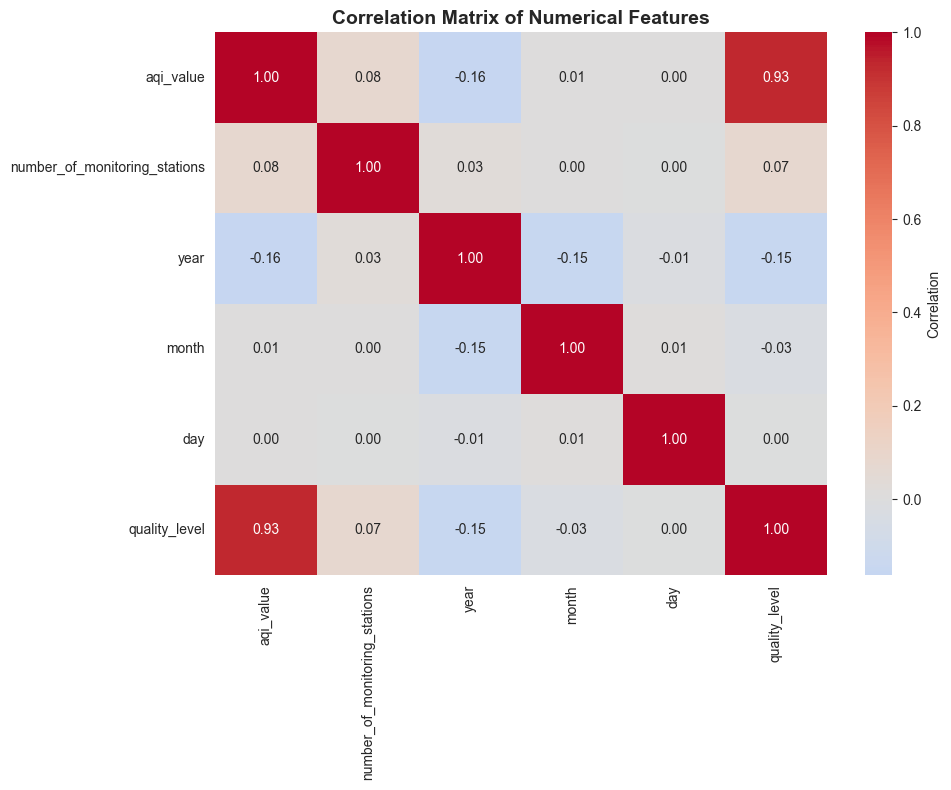

Interpretation:
• Values close to 1: Strong positive relationship
• Values close to -1: Strong negative relationship
• Values close to 0: No relationship


In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("• Values close to 1: Strong positive relationship")
print("• Values close to -1: Strong negative relationship")
print("• Values close to 0: No relationship")

## Compare AQI by Quality Status

In [13]:
print("AQI Statistics by Quality Status:")
print(data.groupby('air_quality_status')['aqi_value'].describe())

print("\n" + "="*60)
print("Average Values by Quality Status:")
stats_by_status = data.groupby('air_quality_status')[['aqi_value', 'number_of_monitoring_stations']].agg(['mean', 'count'])
print(stats_by_status)

AQI Statistics by Quality Status:


                       count        mean        std    min    25%    50%  \
air_quality_status                                                         
Good                 69754.0   38.530091   8.674540    3.0   33.0   40.0   
Moderate            138532.0  139.205086  27.881619   71.0  115.0  134.0   
Poor                 43812.0  243.288962  28.321289  200.0  218.0  240.0   
Satisfactory        155222.0   74.120692  14.315780   25.0   62.0   73.0   
Severe                2567.0  430.652123  23.922911  398.0  411.0  425.0   
Very Poor            15392.0  339.391567  27.213129  300.0  316.0  335.0   

                      75%    max  
air_quality_status                
Good                 46.0   50.0  
Moderate            161.0  200.0  
Poor                266.0  300.0  
Satisfactory         86.0  111.0  
Severe              446.0  500.0  
Very Poor           360.0  400.0  

Average Values by Quality Status:
                     aqi_value         number_of_monitoring_stations        

## AQI Distribution by Status

C:\Users\NITISH RANA\AppData\Local\Temp\ipykernel_516\342280862.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='air_quality_status', y='aqi_value', data=data_sorted, ax=axes[0], palette='Set2')


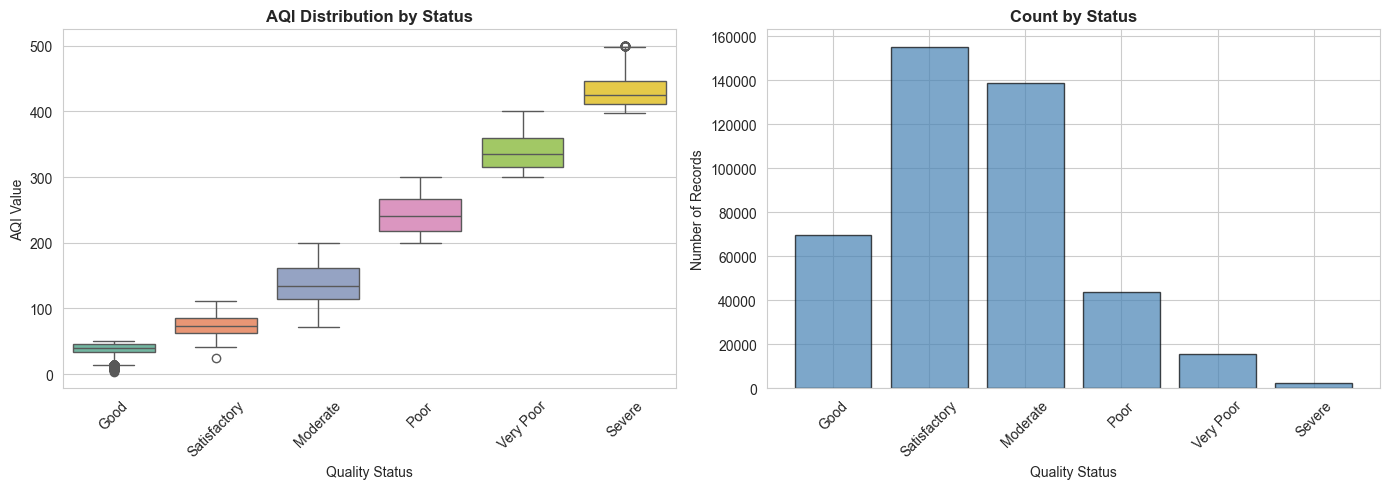

In [14]:
status_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
data_sorted = data.copy()
data_sorted['air_quality_status'] = pd.Categorical(data_sorted['air_quality_status'], categories=status_order, ordered=True)
data_sorted = data_sorted.sort_values('air_quality_status')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(x='air_quality_status', y='aqi_value', data=data_sorted, ax=axes[0], palette='Set2')
axes[0].set_title('AQI Distribution by Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quality Status')
axes[0].set_ylabel('AQI Value')
axes[0].tick_params(axis='x', rotation=45)

# Count plot
status_counts = data['air_quality_status'].value_counts().reindex(status_order)
axes[1].bar(status_order, status_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_title('Count by Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quality Status')
axes[1].set_ylabel('Number of Records')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Compare States

Top 10 States by Average AQI:
                        mean  count         std
state                                          
delhi             215.895080   3679  102.758148
bihar             165.905256  30820   99.692995
himachal pradesh  160.133040   1135   71.701757
uttar pradesh     159.542288  44847  101.617717
haryana           151.533731  50666   89.084867
jharkhand         147.367081   1610   68.186898
rajasthan         130.720200  41501   68.007281
tripura           126.565670   1538   85.011101
odisha            123.680314  13995   68.834668
chandigarh        122.829909   2093   67.902421

Bottom 10 States by Average AQI:
                                  mean  count        std
state                                                   
chhattisgarh                 77.832926   6135  38.878905
tamil nadu                   69.900735  16602  40.401685
kerala                       67.518460  11999  30.077571
karnataka                    64.287702  37810  33.244583
andaman and nicoba

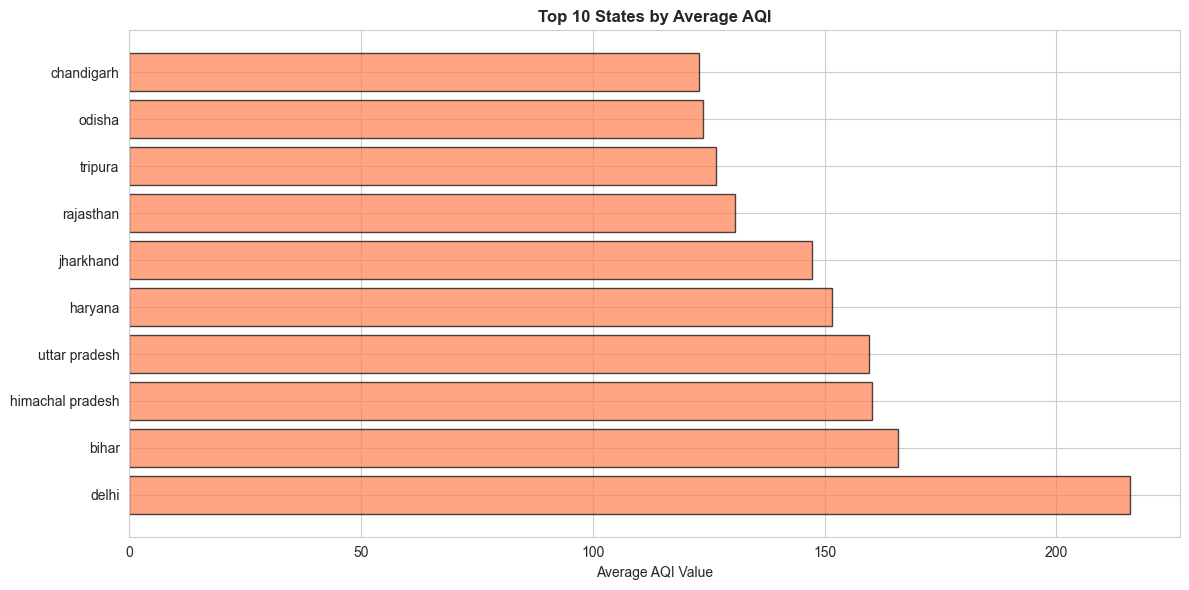

In [15]:
state_stats = data.groupby('state')['aqi_value'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)

print("Top 10 States by Average AQI:")
print(state_stats.head(10))

print("\n" + "="*60)
print("Bottom 10 States by Average AQI:")
print(state_stats.tail(10))

fig, ax = plt.subplots(figsize=(12, 6))
state_means = data.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(10)
ax.barh(state_means.index, state_means.values, color='coral', edgecolor='black', alpha=0.7)
ax.set_title('Top 10 States by Average AQI', fontsize=12, fontweight='bold')
ax.set_xlabel('Average AQI Value')
plt.tight_layout()
plt.show()

## Summary

In [16]:
status_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
state_stats = data.groupby('state')['aqi_value'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60 + "\n")

print("1. Dataset Overview:")
print(f"   • Total records: {len(data):,}")
print(f"   • States covered: {data['state'].nunique()}")
print(f"   • AQI range: {data['aqi_value'].min():.0f} to {data['aqi_value'].max():.0f}")

print("\n2. Quality Status Distribution:")
for status in status_order:
    count = len(data[data['air_quality_status'] == status])
    pct = (count / len(data)) * 100
    print(f"   • {status}: {count:,} ({pct:.1f}%)")

print("\n3. Most Polluted States (Top 5):")
for i, (state, val) in enumerate(state_stats.head(5)['mean'].items(), 1):
    print(f"   {i}. {state}: {val:.1f}")

print("\n4. Cleanest States (Top 5):")
for i, (state, val) in enumerate(state_stats.tail(5)['mean'].items(), 1):
    print(f"   {i}. {state}: {val:.1f}")

print("\n5. Correlation with AQI:")
corr_with_aqi = data[['aqi_value', 'quality_level', 'month', 'year']].corr()['aqi_value'].drop('aqi_value')
for col, val in corr_with_aqi.items():
    print(f"   • {col}: {val:.3f}")

print("\n" + "="*60)


KEY FINDINGS

1. Dataset Overview:
   • Total records: 425,279
   • States covered: 32
   • AQI range: 3 to 500

2. Quality Status Distribution:
   • Good: 69,754 (16.4%)
   • Satisfactory: 155,222 (36.5%)
   • Moderate: 138,532 (32.6%)
   • Poor: 43,812 (10.3%)
   • Very Poor: 15,392 (3.6%)
   • Severe: 2,567 (0.6%)

3. Most Polluted States (Top 5):
   1. delhi: 215.9
   2. bihar: 165.9
   3. himachal pradesh: 160.1
   4. uttar pradesh: 159.5
   5. haryana: 151.5

4. Cleanest States (Top 5):
   1. arunachal pradesh: 59.9
   2. puducherry: 56.0
   3. sikkim: 53.5
   4. meghalaya: 52.6
   5. mizoram: 45.1

5. Correlation with AQI:
   • quality_level: 0.935
   • month: 0.006
   • year: -0.163

